# Monte Carlo pricing & stochastic simulations

This notebook demonstrates a selection of capabilities of the **Volaris** library:
- European, Asian, and barrier option pricing via Monte Carlo simulation
- GBM path simulation with antithetic variates for variance reduction
- Merton jump-diffusion model (GBM + compound Poisson jumps)
- GARCH(1,1) volatility modelling and forecasting

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from volaris import (
    bs_price,
    mc_price_european, mc_price_asian, mc_price_barrier,
    gbm_paths, gbm_paths_antithetic,
    merton_paths,
    garch_fit, garch_variances, garch_forecast,
)

S, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

---

## European option pricing

Monte Carlo estimates the option price by simulating many asset paths and averaging the discounted payoffs.

Comparison against the Black-Scholes analytical price:

In [2]:
bs_ref = bs_price(S, K, T, r, sigma, 1)

path_counts = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]
prices, errors = [], []

for N in path_counts:
    price, se = mc_price_european(S, K, T, r, sigma, N, 1)
    prices.append(price)
    errors.append(se)

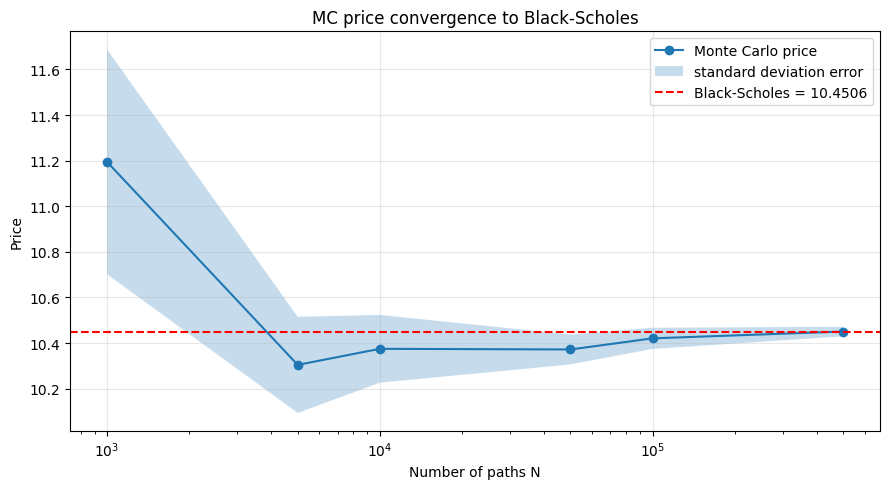

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(path_counts, prices, "o-", label="Monte Carlo price")
ax.fill_between(path_counts, 
                [p - e for p, e in zip(prices, errors)],
                [p + e for p, e in zip(prices, errors)],
                alpha=0.25, label="standard deviation error")
ax.axhline(bs_ref, color="red", ls="--", label=f"Black-Scholes = {bs_ref:.4f}")
ax.set_xlabel("Number of paths N"); ax.set_ylabel("Price")
ax.set_title("MC price convergence to Black-Scholes")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## Asian and barrier options

Exotic options depend on the full path, not just the terminal price: they cannot be priced analytically with a simple closed form.

- *Asian option*: payoff based on the average price over the life of the option

- *Barrier option*: activated (knock-in) or deactivated (knock-out) when price crosses a barrier B

In [4]:
N_paths, N_steps = 100_000, 252
B = 120.0  # barrier level

european, _ = mc_price_european(S, K, T, r, sigma, N_paths, 1)
asian = mc_price_asian(S, K, T, r, sigma, N_paths, N_steps, 1)
knockout = mc_price_barrier(S, K, T, r, sigma, N_paths, N_steps, B, 1, 1, 1)
knockin = mc_price_barrier(S, K, T, r, sigma, N_paths, N_steps, B, 1, 0, 1)

print(f"European call:    {european:.4f}")
print(f"Asian call:       {asian:.4f}")
print(f"Up-and-out call:  {knockout:.4f}")
print(f"Up-and-in call:   {knockin:.4f}")
print(f"\nKnock-out + knock-in = {knockout + knockin:.4f}  (should more-less equal European = {european:.4f})")

European call:    10.4207
Asian call:       5.8314
Up-and-out call:  1.3488
Up-and-in call:   9.1639

Knock-out + knock-in = 10.5127  (should more-less equal European = 10.4207)


---

## Geometric Brownian Motion paths simulation

Simulating asset paths under Geometric Brownian Motion. 

Antithetic variates pair each path with its mirror (-Z instead of Z), reducing variance without additional model evaluations.

In [5]:
N_plot, N_steps = 200, 252

paths = gbm_paths(S, mu=0.05, sigma=sigma, T=1.0, N_steps=N_steps, N_paths=N_plot)
paths_anti = gbm_paths_antithetic(S, mu=0.05, sigma=sigma, T=1.0, N_steps=N_steps, N_paths=N_plot)

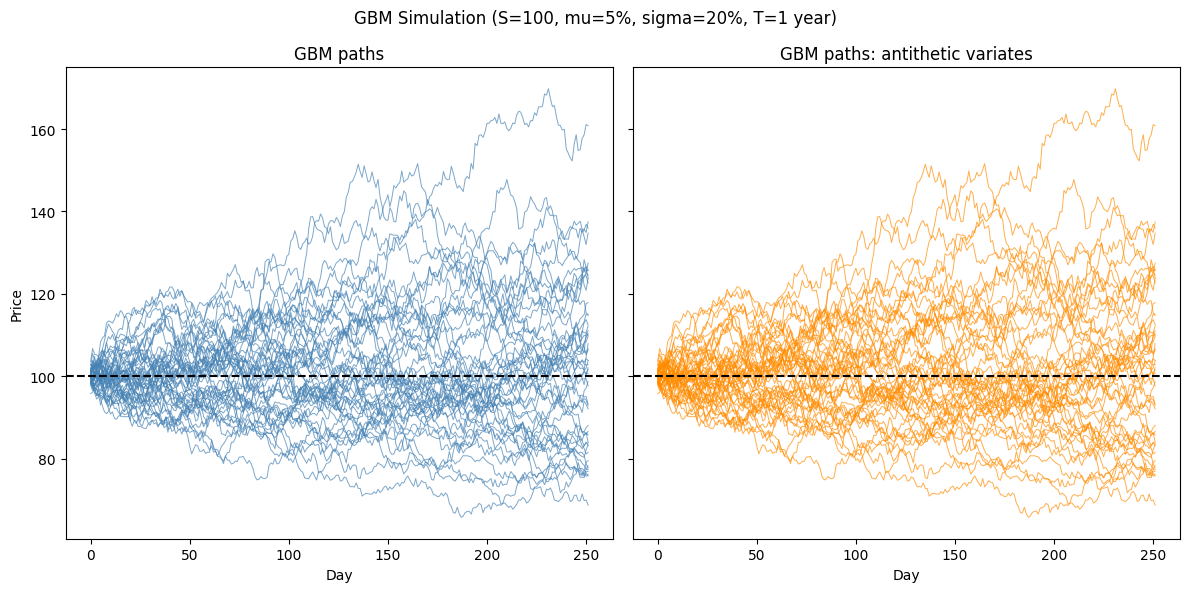

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for p in paths[:50]:
    axes[0].plot(p, alpha=0.7, lw=0.7, color="steelblue")
axes[0].set_title("GBM paths"); axes[0].set_xlabel("Day"); axes[0].set_ylabel("Price")
axes[0].axhline(S, ls="--", color="black")

for p in paths_anti[:50]:
    axes[1].plot(p, alpha=0.7, lw=0.7, color="darkorange")
axes[1].set_title("GBM paths: antithetic variates")
axes[1].set_xlabel("Day")
axes[1].axhline(S, ls="--", color="black")

plt.suptitle("GBM Simulation (S=100, mu=5%, sigma=20%, T=1 year)")
plt.tight_layout()
plt.show()

---

## Merton jump-diffusion model

The Merton model extends GBM by adding compound Poisson jumps: sudden large moves that GBM cannot capture.

Parameters:
| Symbol | Meaning |
|--------|---------|
| lambda | expected number of jumps per year |
| mu_j | mean log-jump size |
| sigma_j | volatility of log-jump size |

In [7]:
N_plot = 50

gbm_sim = gbm_paths(S, mu=0.05, sigma=0.15, T=1.0, N_steps=252, N_paths=N_plot)
merton_sim = merton_paths(S, mu=0.05, sigma=0.15, lambda_=5.0, mu_j=-0.05, 
                          sigma_j=0.10, T=1.0, N_steps=252, N_paths=N_plot)

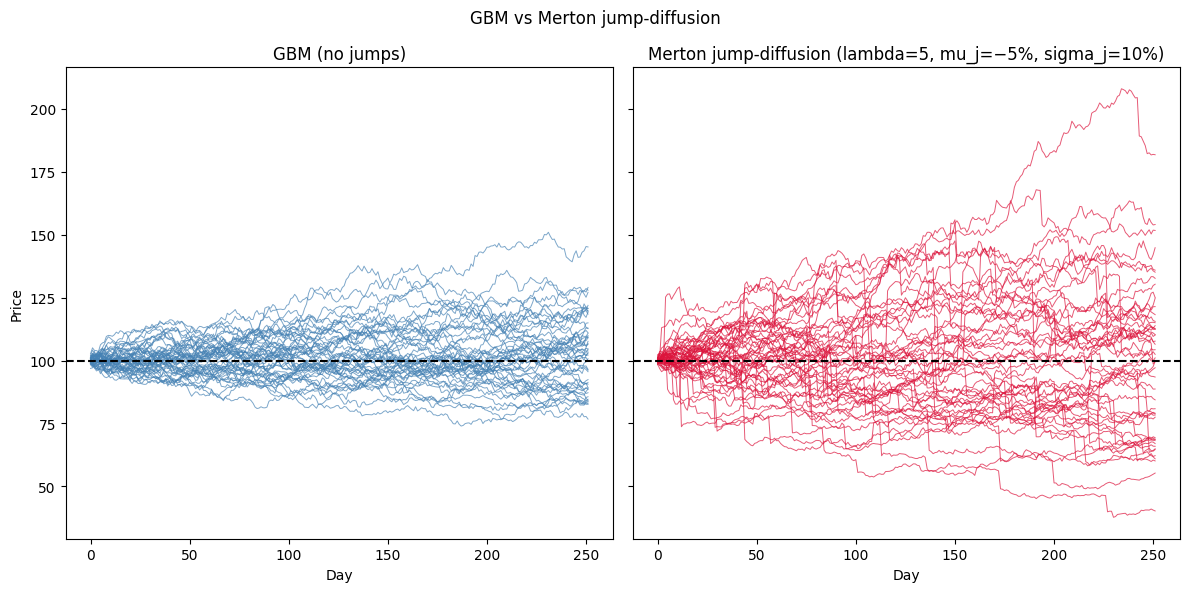

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for p in gbm_sim:
    axes[0].plot(p, alpha=0.7, lw=0.7, color="steelblue")
axes[0].set_title("GBM (no jumps)"); axes[0].set_xlabel("Day"); axes[0].set_ylabel("Price")
axes[0].axhline(S, ls="--", color="black")

for p in merton_sim:
    axes[1].plot(p, alpha=0.7, lw=0.7, color="crimson")
axes[1].set_title("Merton jump-diffusion (lambda=5, mu_j=−5%, sigma_j=10%)")
axes[1].set_xlabel("Day")
axes[1].axhline(S, ls="--", color="black")

plt.suptitle("GBM vs Merton jump-diffusion")
plt.tight_layout()
plt.show()

---

## GARCH(1, 1) volatility modelling

GARCH(1,1) models **volatility clustering**: the observation that large moves tend to follow large moves. 

It fits a time-varying variance: `(sigma_t)^2 = omega + alpha * (eps_{t-1})^2 + beta * (sigma_{t+1})^2`.

We simulate returns with time-varying volatility, fit GARCH(1,1), and forecast.

In [9]:
# Simulate returns with volatility clustering

np.random.seed(123)
n = 1000
omega, alpha, beta = 0.0001, 0.10, 0.85

var = np.zeros(n)
ret = np.zeros(n)
var[0] = omega / (1 - alpha - beta)
for t in range(1, n):
    ret[t] = np.sqrt(var[t-1]) * np.random.randn()
    var[t] = omega + alpha * ret[t]**2 + beta * var[t-1]

returns = np.ascontiguousarray(ret[1:])

In [10]:
# Fit GARCH(1,1)
params = garch_fit(returns.tolist())
print(f"True:      omega={omega:.6f} | alpha={alpha:.6f} | beta={beta:.6f}")
print(f"Fitted:    omega={params['omega']:.6f} | alpha={params['alpha']:.6f} | beta={params['beta']:.6f}")            

variances = garch_variances(params['omega'], params['alpha'], params['beta'], returns.tolist())
forecast = garch_forecast(params['omega'], params['alpha'], params['beta'], returns.tolist(), 21)

True:      omega=0.000100 | alpha=0.100000 | beta=0.850000
Fitted:    omega=0.000087 | alpha=0.077514 | beta=0.878238


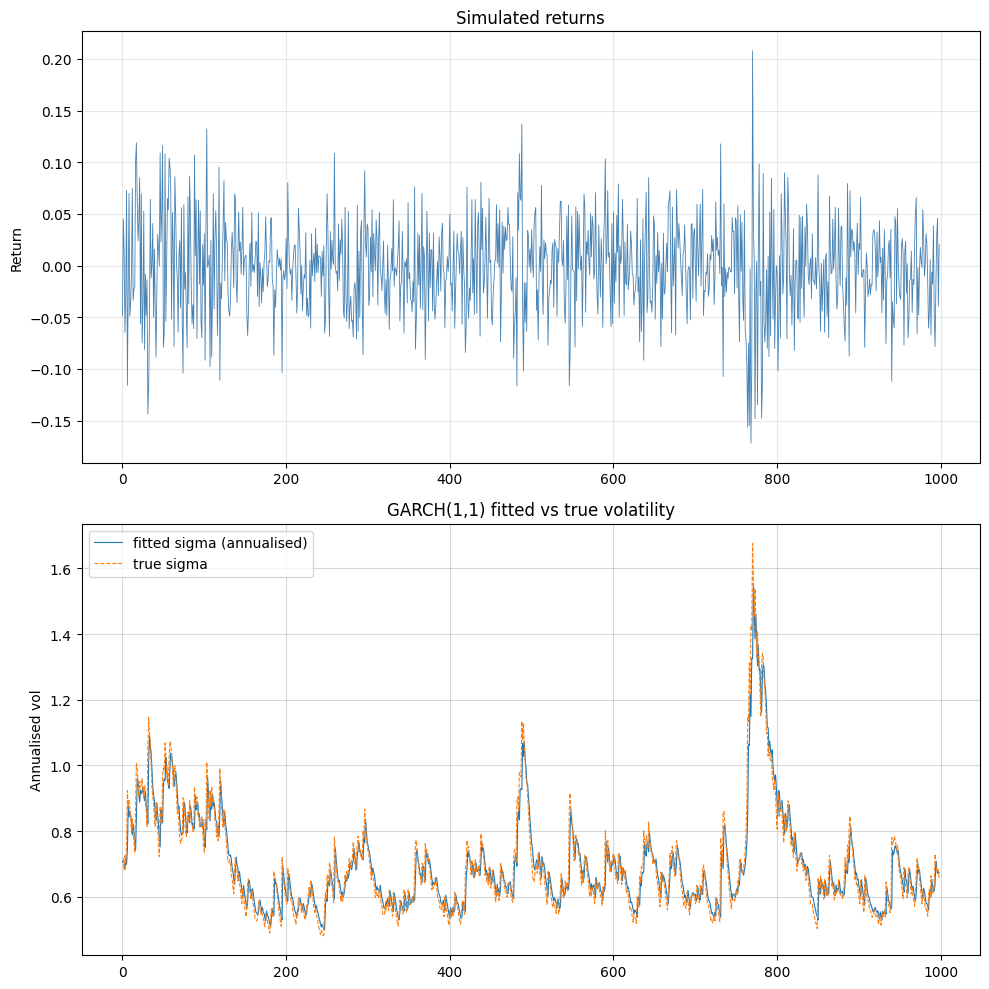

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

axes[0].plot(returns, lw=0.6, color="steelblue")
axes[0].set_title("Simulated returns")
axes[0].set_ylabel("Return")
axes[0].grid(alpha=0.3)

axes[1].plot(np.sqrt(variances) * np.sqrt(252), lw=0.8, label="fitted sigma (annualised)")
axes[1].plot(np.sqrt(var[1:]) * np.sqrt(252), lw=0.8, ls="--", label="true sigma")
axes[1].set_title("GARCH(1,1) fitted vs true volatility")
axes[1].set_ylabel("Annualised vol")
axes[1].legend()
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.show()